In [8]:
# Imports
import rasterio
import rasterio.plot
from rasterio.windows import Window
import geopandas as gpd
from rasterio.mask import mask
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import pearsonr

Quickly comparing the hex vs square grid outputs (by swapping the file path below)

In [9]:
# the new hex grid option

# park_vga = gpd.read_file("../../outputs/method_02_hex/Woodhouse_Moor_10_m_grid_100m_vis_hex.geojson")
park_vga = gpd.read_file("../../outputs/method_03_hex/Woodhouse_Moor_10_m_grid_hex_buffer_100m_vis_hex.geojson")
park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
park_vga.head()

TARGET_CRS = 'EPSG:27700'

# Ok, again I will have to convert the CRS
park_vga_bng = park_vga.to_crs(epsg=27700)

In [10]:
print(f"Original park CRS: {park_gdf.crs}")

# Reproject park to target CRS if needed
if park_gdf.crs != TARGET_CRS:
    park_gdf = park_gdf.to_crs(TARGET_CRS)
    print(f"Reprojected park to {TARGET_CRS}")
else:
    print(f"Park already in {TARGET_CRS}")

# Extract park boundary geometry (now in EPSG:27700)
park_boundary = park_gdf.geometry.iloc[0]
print(f"Park boundary CRS: {park_gdf.crs}")

Original park CRS: EPSG:4326
Reprojected park to EPSG:27700
Park boundary CRS: EPSG:27700


<Axes: >

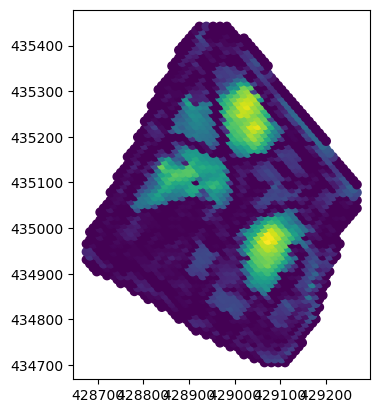

In [11]:
park_vga_bng.plot(column='visibility_pct')

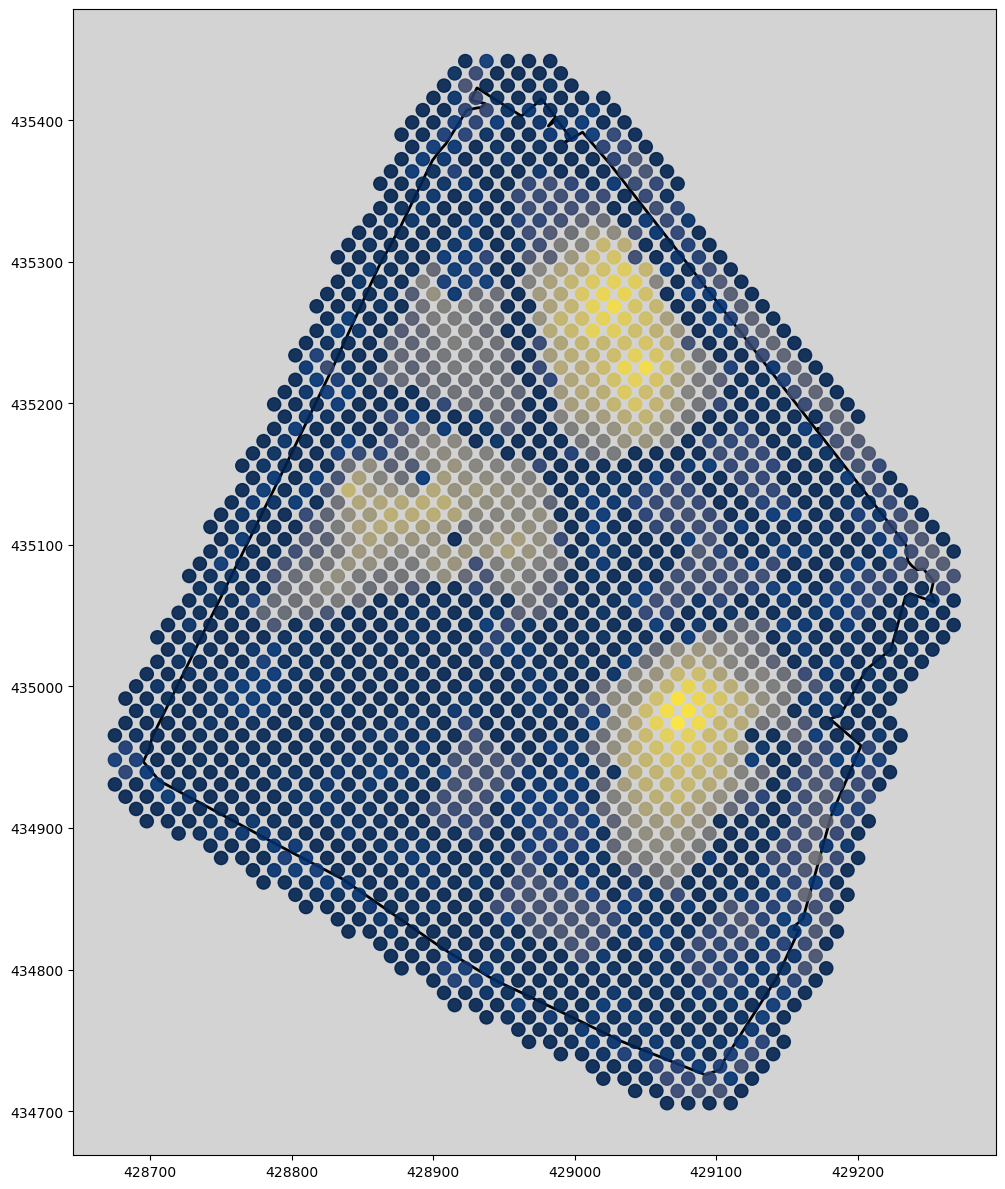

In [12]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('lightgrey')
park_gdf.boundary.plot(ax=ax, color='black', linewidth=2, zorder=0)
park_vga_bng.plot(column='visibility_pct', cmap="cividis", ax=ax, markersize=90, alpha=0.9)
plt.tight_layout()
plt.show()